In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split

%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv('../../data/laptop_data.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [4]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [5]:
df_stats_numeric = df.describe ( )
df_stats_numeric

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [6]:
print("Checking unique values in RAM, Memory, Weight:")
print(df['Ram'].unique())
print(df['Memory'].unique())
print(df['Weight'].unique())

Checking unique values in RAM, Memory, Weight:
['8GB' '16GB' '4GB' '2GB' '12GB' '6GB' '32GB' '24GB' '64GB']
['128GB SSD' '128GB Flash Storage' '256GB SSD' '512GB SSD' '500GB HDD'
 '256GB Flash Storage' '1TB HDD' '32GB Flash Storage'
 '128GB SSD +  1TB HDD' '256GB SSD +  256GB SSD' '64GB Flash Storage'
 '256GB SSD +  1TB HDD' '256GB SSD +  2TB HDD' '32GB SSD' '2TB HDD'
 '64GB SSD' '1.0TB Hybrid' '512GB SSD +  1TB HDD' '1TB SSD'
 '256GB SSD +  500GB HDD' '128GB SSD +  2TB HDD' '512GB SSD +  512GB SSD'
 '16GB SSD' '16GB Flash Storage' '512GB SSD +  256GB SSD'
 '512GB SSD +  2TB HDD' '64GB Flash Storage +  1TB HDD' '180GB SSD'
 '1TB HDD +  1TB HDD' '32GB HDD' '1TB SSD +  1TB HDD'
 '512GB Flash Storage' '128GB HDD' '240GB SSD' '8GB SSD' '508GB Hybrid'
 '1.0TB HDD' '512GB SSD +  1.0TB Hybrid' '256GB SSD +  1.0TB Hybrid']
['1.37kg' '1.34kg' '1.86kg' '1.83kg' '2.1kg' '2.04kg' '1.3kg' '1.6kg'
 '2.2kg' '0.92kg' '1.22kg' '0.98kg' '2.5kg' '1.62kg' '1.91kg' '2.3kg'
 '1.35kg' '1.88kg' '1.89kg' '1.65

In [ ]:
DROPPING THE UNIQUE COLUMN

In [7]:
df.drop ( columns = [ 'Unnamed: 0' ] , inplace = True )
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
EXPLORATORY DATA ANALYSIS
EXTRACTING COLUMNS

In [8]:
# Feature: TouchScreen
df['TouchScreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

# Feature: IPS Panel
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

# Feature: HD or 4K Screen
df['HD_4K'] = df['ScreenResolution'].apply(lambda x: 1 if '4K' in x or 'HD' in x or 'HD+' in x else 0)

# Feature: CPU Brand
df['CPU_Brand'] = df['Cpu'].apply(
    lambda x: 'Samsung' if 'Samsung' in x else ('Intel' if 'Intel' in x else ('AMD' if 'AMD' in x else 'Other'))
)

# Feature: GPU Brand
df['GPU_Brand'] = df['Gpu'].apply(lambda x: 'Nvidia' if 'Nvidia' in x else ('AMD' if 'AMD' in x else 'Intel'))

# Feature: Memory Type (Improved logic)
def memory_type(mem):
    if 'HDD' in mem and 'SSD' in mem:
        return 'Hybrid'
    elif 'HDD' in mem:
        return 'HDD'
    elif 'SSD' in mem:
        return 'SSD'
    elif 'Flash' in mem:
        return 'Flash Storage'
    else:
        return 'Other'
df['Memory_Type'] = df['Memory'].apply(memory_type)

# Feature: CPU Frequency (GHz)
df['CPU_Frequency'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz', expand=True)[0]
df['CPU_Frequency'] = pd.to_numeric(df['CPU_Frequency'], errors='coerce')

In [9]:
df_Original = df.copy()
# Feature: PPI (Pixel Density)
pixels = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
pixels = pixels.astype('float')
df['Length'] = pixels[0]
df['Width'] = pixels[1]
df['PPI'] = ( (df['Length']**2 + df['Width']**2) ** 0.5 ) / df['Inches']

# Clean: Convert RAM and Weight to numeric
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int64')
df['Weight'] = df['Weight'].str.replace('kg', '').astype('float64')

In [ ]:
DATA VISUALIZATION

### Key Point

- Visualizing how key features like `Company`, `TypeName`, `Inches`, and `Ram` relate to the laptop `Price`.
- Bar plots are used for categorical features to compare average prices.
- Scatter plots are used for numerical features to observe price trends or patterns.

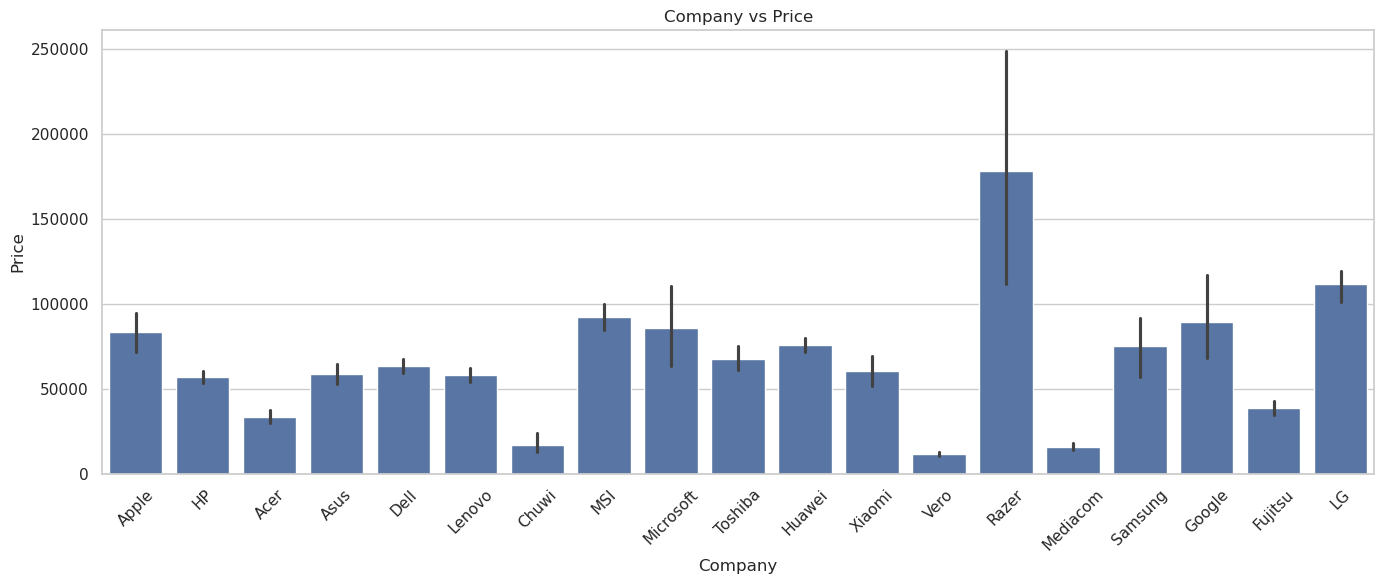

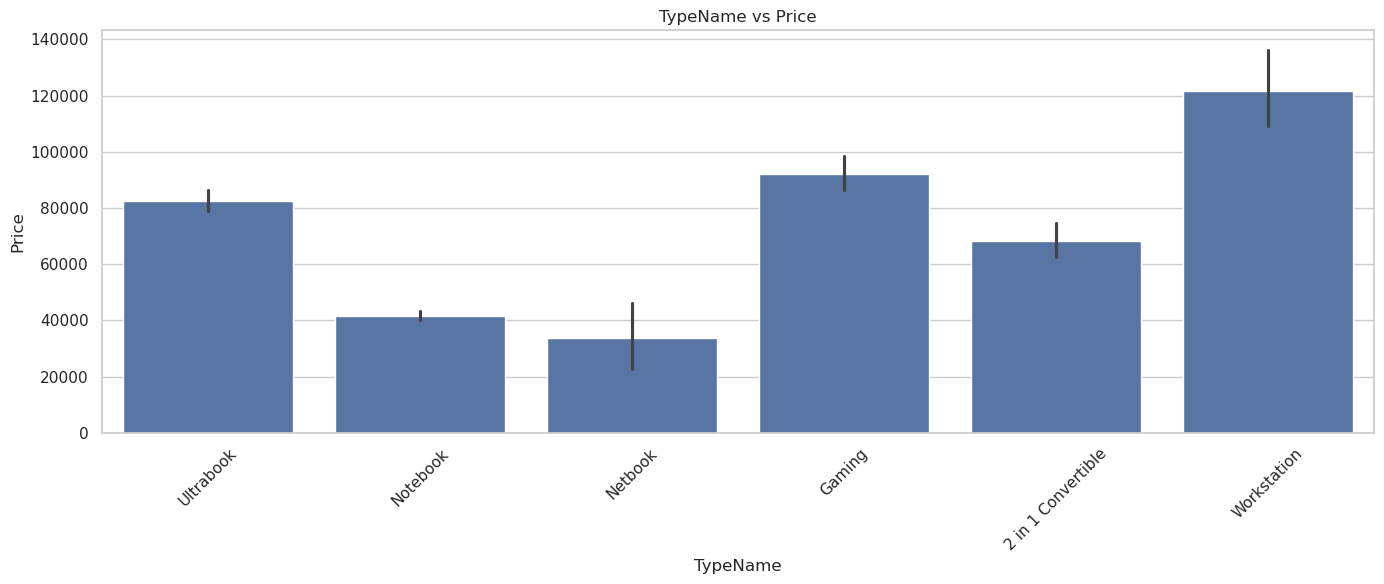

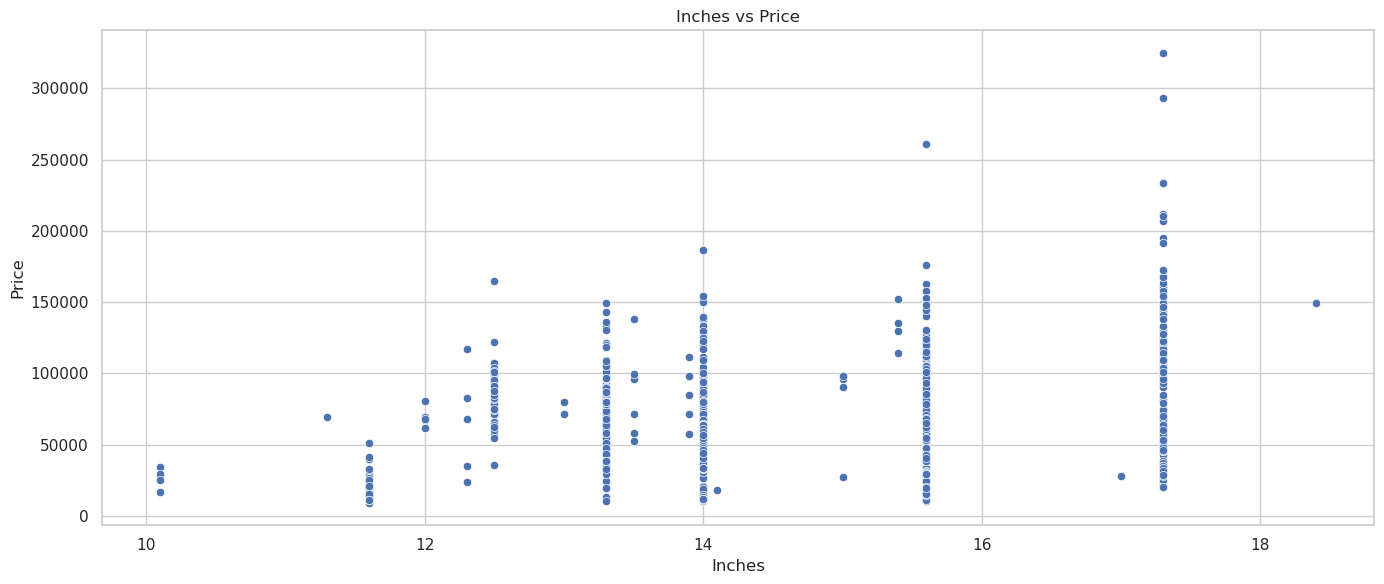

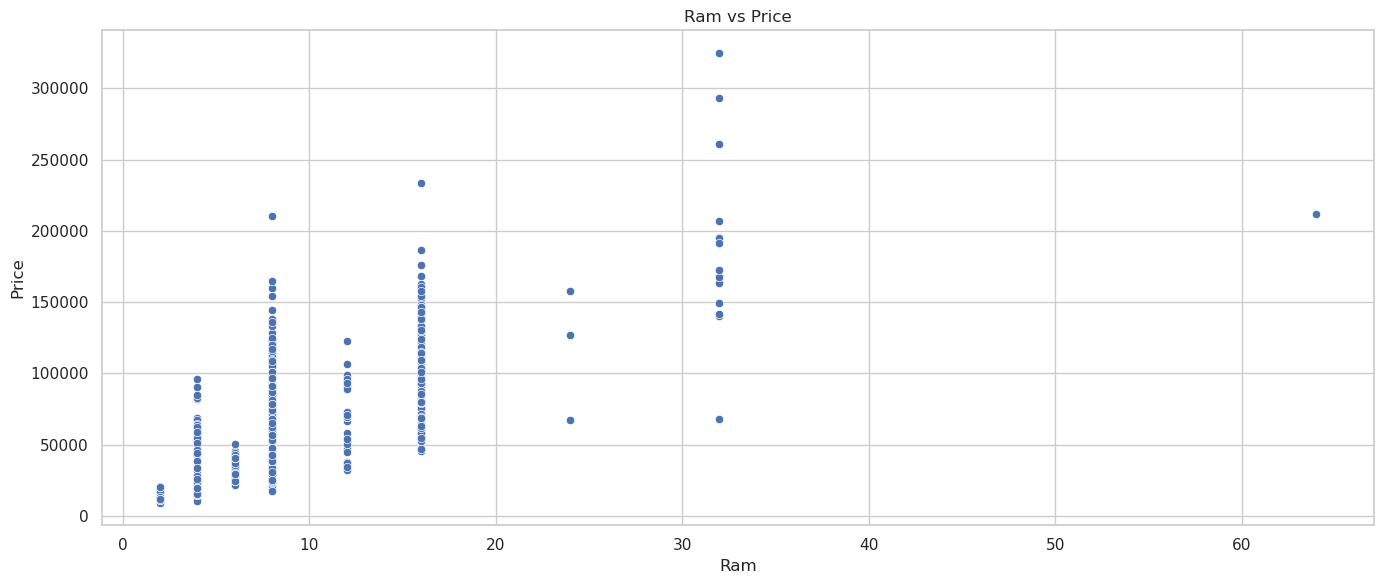

In [10]:
sns.set(style="whitegrid")
for col in ['Company', 'TypeName', 'Inches', 'Ram']:  # choose relevant cols
    plt.figure(figsize=(14,6))
    if df[col].dtype == 'object':
        sns.barplot(x=col, y='Price', data=df)
        plt.xticks(rotation=45)
    else:
        sns.scatterplot(x=col, y='Price', data=df)
    plt.title(f"{col} vs Price")
    plt.tight_layout()
    plt.show()


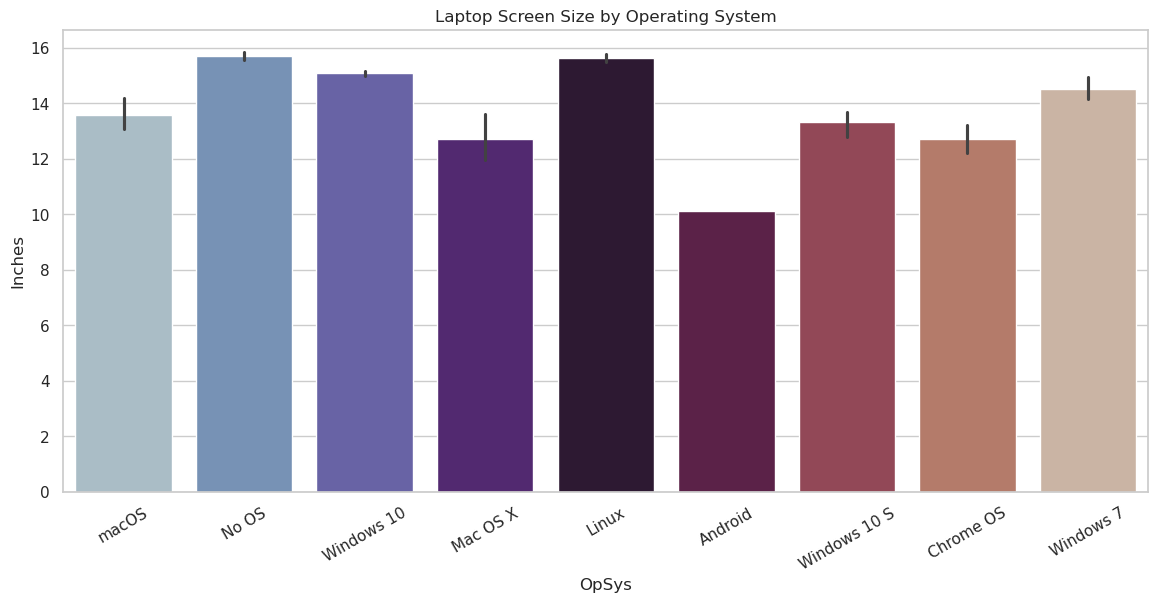

In [11]:
plt.figure(figsize=(14,6))
sns.barplot(x='OpSys', y='Inches', data=df, palette='twilight')
plt.title("Laptop Screen Size by Operating System")
plt.xticks(rotation=30)
plt.show()

<Axes: xlabel='Price', ylabel='Count'>

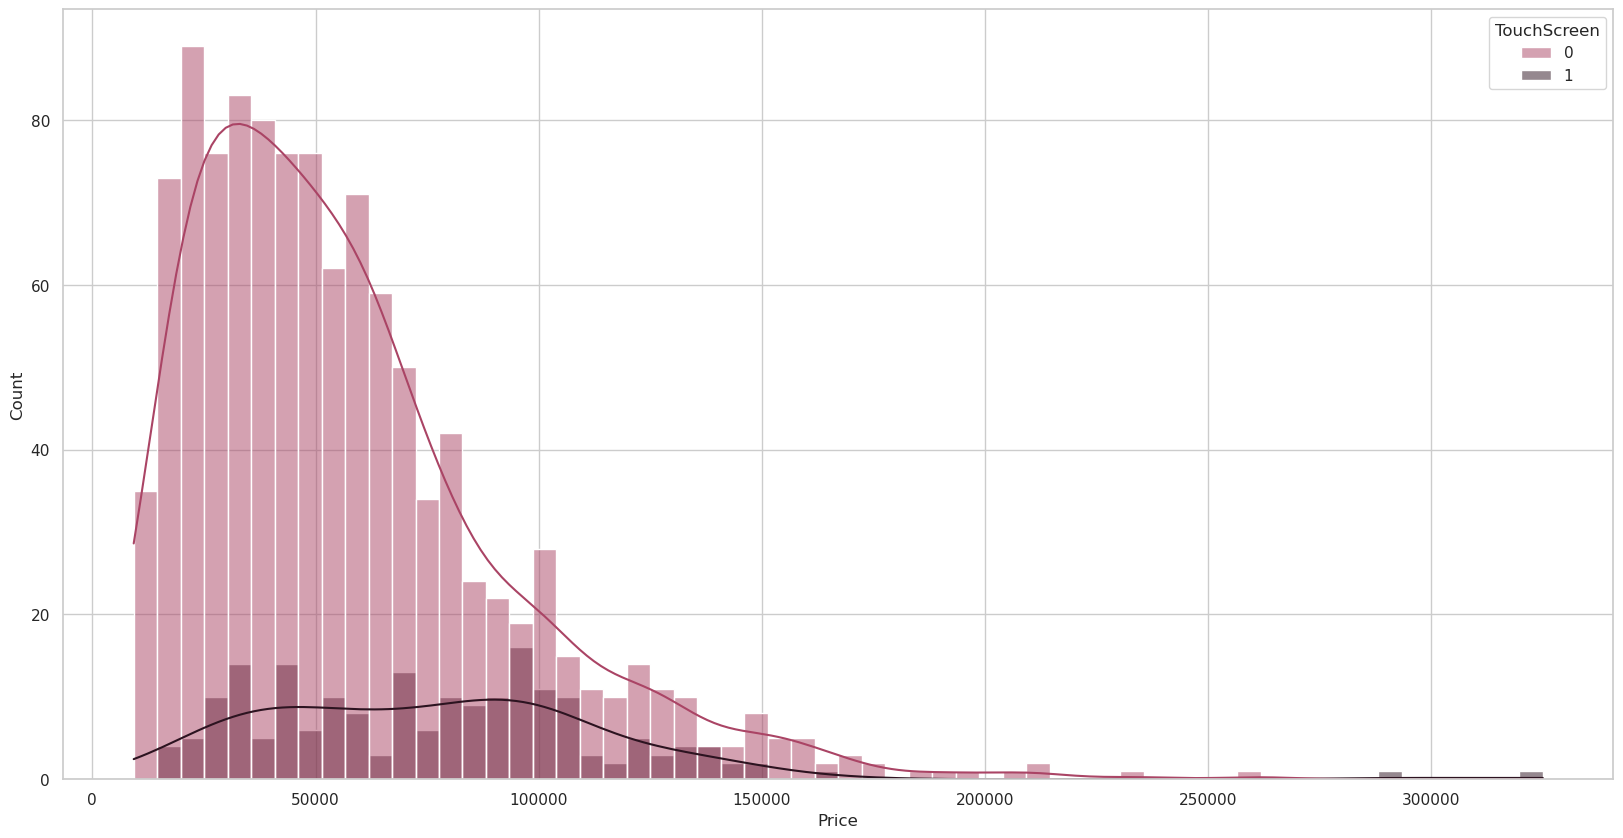

In [12]:
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='Price', kde=True, hue='TouchScreen', palette=['#AA4465', '#2C1320'], bins=60)

<Axes: xlabel='Ram', ylabel='Count'>

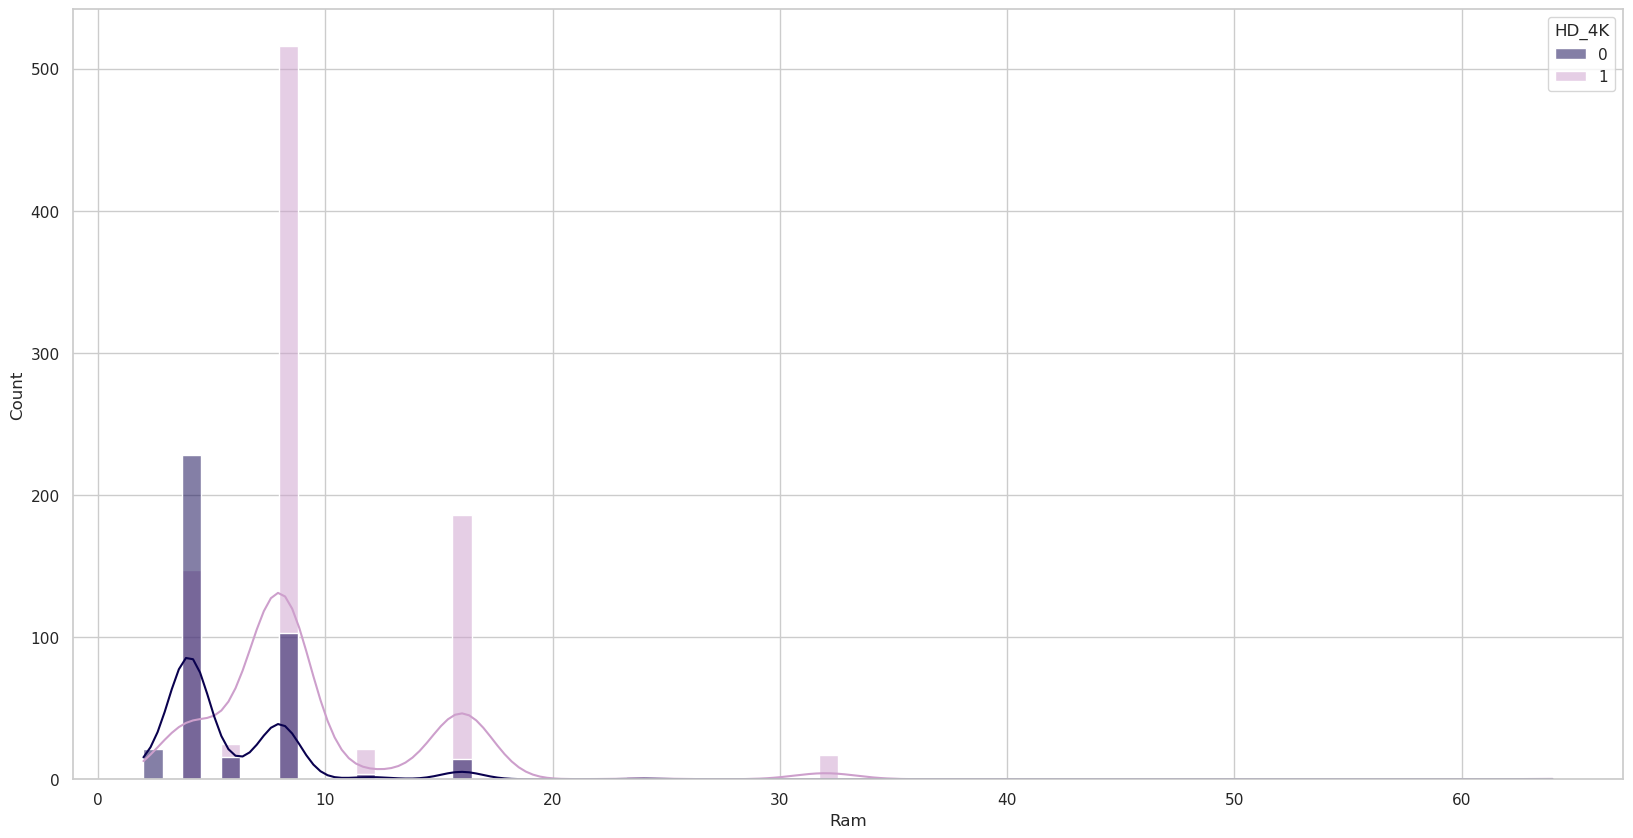

In [13]:
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='Ram', kde=True, hue='HD_4K', palette=['#0A014F', '#CD9FCC'])

### Key Point

- This pie chart shows how touchscreen laptops are distributed across different laptop types.
- Helps identify which types (e.g., Ultrabook, Notebook, etc.) commonly include touchscreen features.

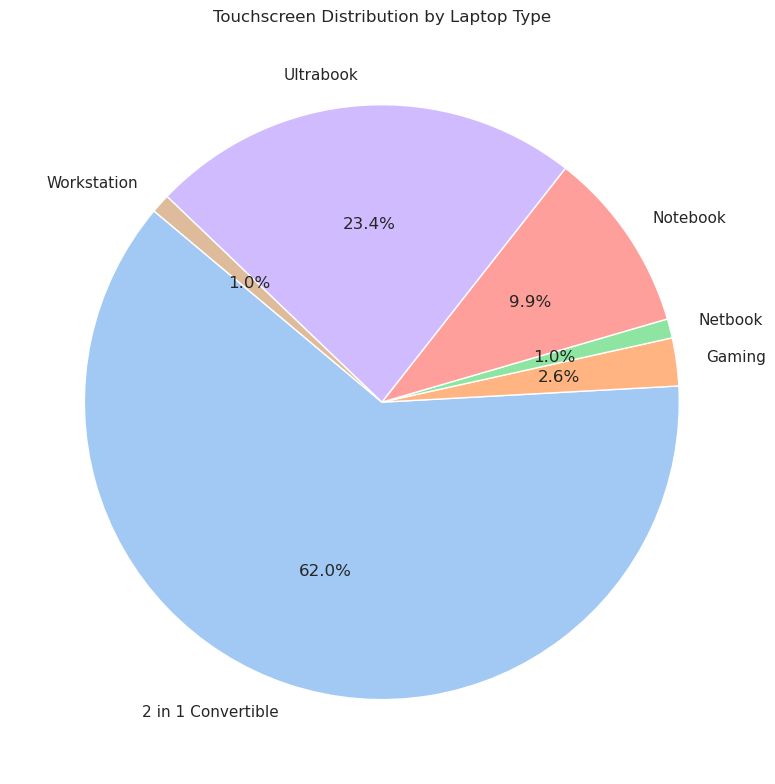

In [14]:
Data = df.groupby('TypeName')['TouchScreen'].sum().reset_index()
plt.figure(figsize=(12, 8))
colors = sns.color_palette("pastel")
plt.pie(Data['TouchScreen'], labels=Data['TypeName'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Touchscreen Distribution by Laptop Type")
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Apple'),
  Text(1, 0, 'HP'),
  Text(2, 0, 'Acer'),
  Text(3, 0, 'Asus'),
  Text(4, 0, 'Dell'),
  Text(5, 0, 'Lenovo'),
  Text(6, 0, 'Chuwi'),
  Text(7, 0, 'MSI'),
  Text(8, 0, 'Microsoft'),
  Text(9, 0, 'Toshiba'),
  Text(10, 0, 'Huawei'),
  Text(11, 0, 'Xiaomi'),
  Text(12, 0, 'Vero'),
  Text(13, 0, 'Razer'),
  Text(14, 0, 'Mediacom'),
  Text(15, 0, 'Samsung'),
  Text(16, 0, 'Google'),
  Text(17, 0, 'Fujitsu'),
  Text(18, 0, 'LG')])

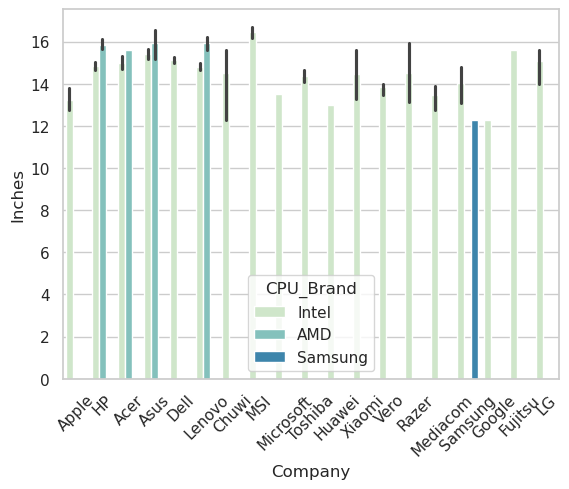

In [15]:
sns.barplot(x='Company', y='Inches', hue='CPU_Brand', data=df, palette='GnBu')
plt.xticks(rotation=45)

In [16]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,HD_4K,CPU_Brand,GPU_Brand,Memory_Type,CPU_Frequency,Length,Width,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,0,Intel,Intel,SSD,2.3,2560.0,1600.0,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,0,Intel,Intel,Flash Storage,1.8,1440.0,900.0,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1,Intel,Intel,SSD,2.5,1920.0,1080.0,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,0,Intel,AMD,SSD,2.7,2880.0,1800.0,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,0,Intel,Intel,SSD,3.1,2560.0,1600.0,226.983005


In [ ]:
OUTLIERS
DETECTING OUTLIERS

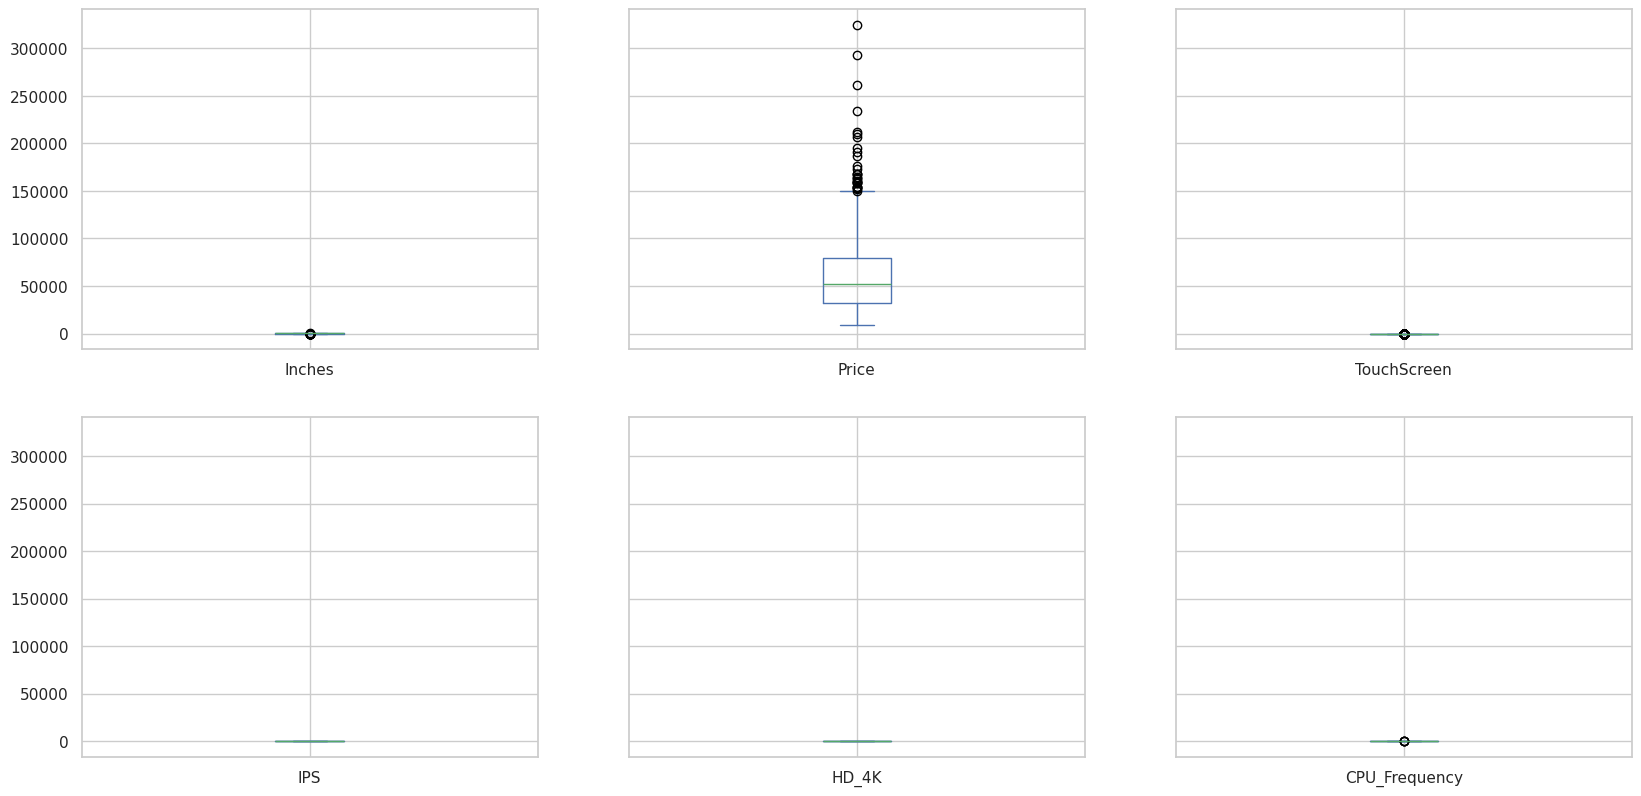

In [17]:
df_Original.select_dtypes ( np.number ).plot ( kind = 'box' , subplots = True , layout = ( 3 , 3 ) , figsize = ( 20 , 15 ) , sharex = True , sharey = True );

In [18]:
mean_price = df['Price'].mean()
std_price = df['Price'].std()
threshold = 3

lower_limit = mean_price - threshold * std_price
upper_limit = mean_price + threshold * std_price

df['Price'] = df['Price'].apply(lambda x: lower_limit if x < lower_limit else (upper_limit if x > upper_limit else x))

In [19]:
df['Price'] = np.log1p(df['Price'])
df['Weight'] = np.log1p(df['Weight'])
df['PPI'] = np.log1p(df['PPI'])


### Outlier Fix & Log Transform:

- Outliers in `Price` are capped using z-score thresholds.
- Features like `Price`, `Weight`, and `PPI` are skewed → applied `log1p` transformation to normalize their distributions.


In [20]:
print('The null values in the dataset are:\n')
print(df.isnull().sum()[df.isnull().sum() > 0])

The null values in the dataset are:

Series([], dtype: int64)


In [21]:
categorical_columns = df.select_dtypes('object').columns.to_list()
categorical_columns

['Company',
 'TypeName',
 'ScreenResolution',
 'Cpu',
 'Memory',
 'Gpu',
 'OpSys',
 'CPU_Brand',
 'GPU_Brand',
 'Memory_Type']

In [22]:
for col in categorical_columns:
    print(f"\n{'-'*70}\nColumn => {col}")
    display(df[col].value_counts())


----------------------------------------------------------------------
Column => Company


Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64


----------------------------------------------------------------------
Column => TypeName


TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64


----------------------------------------------------------------------
Column => ScreenResolution


...

CPU_Brand
Intel      1240
AMD          62
Samsung       1
Name: count, dtype: int64


----------------------------------------------------------------------
Column => GPU_Brand


GPU_Brand
Intel     723
Nvidia    400
AMD       180
Name: count, dtype: int64


----------------------------------------------------------------------
Column => Memory_Type


Memory_Type
SSD              643
HDD              376
Hybrid           200
Flash Storage     74
Other             10
Name: count, dtype: int64

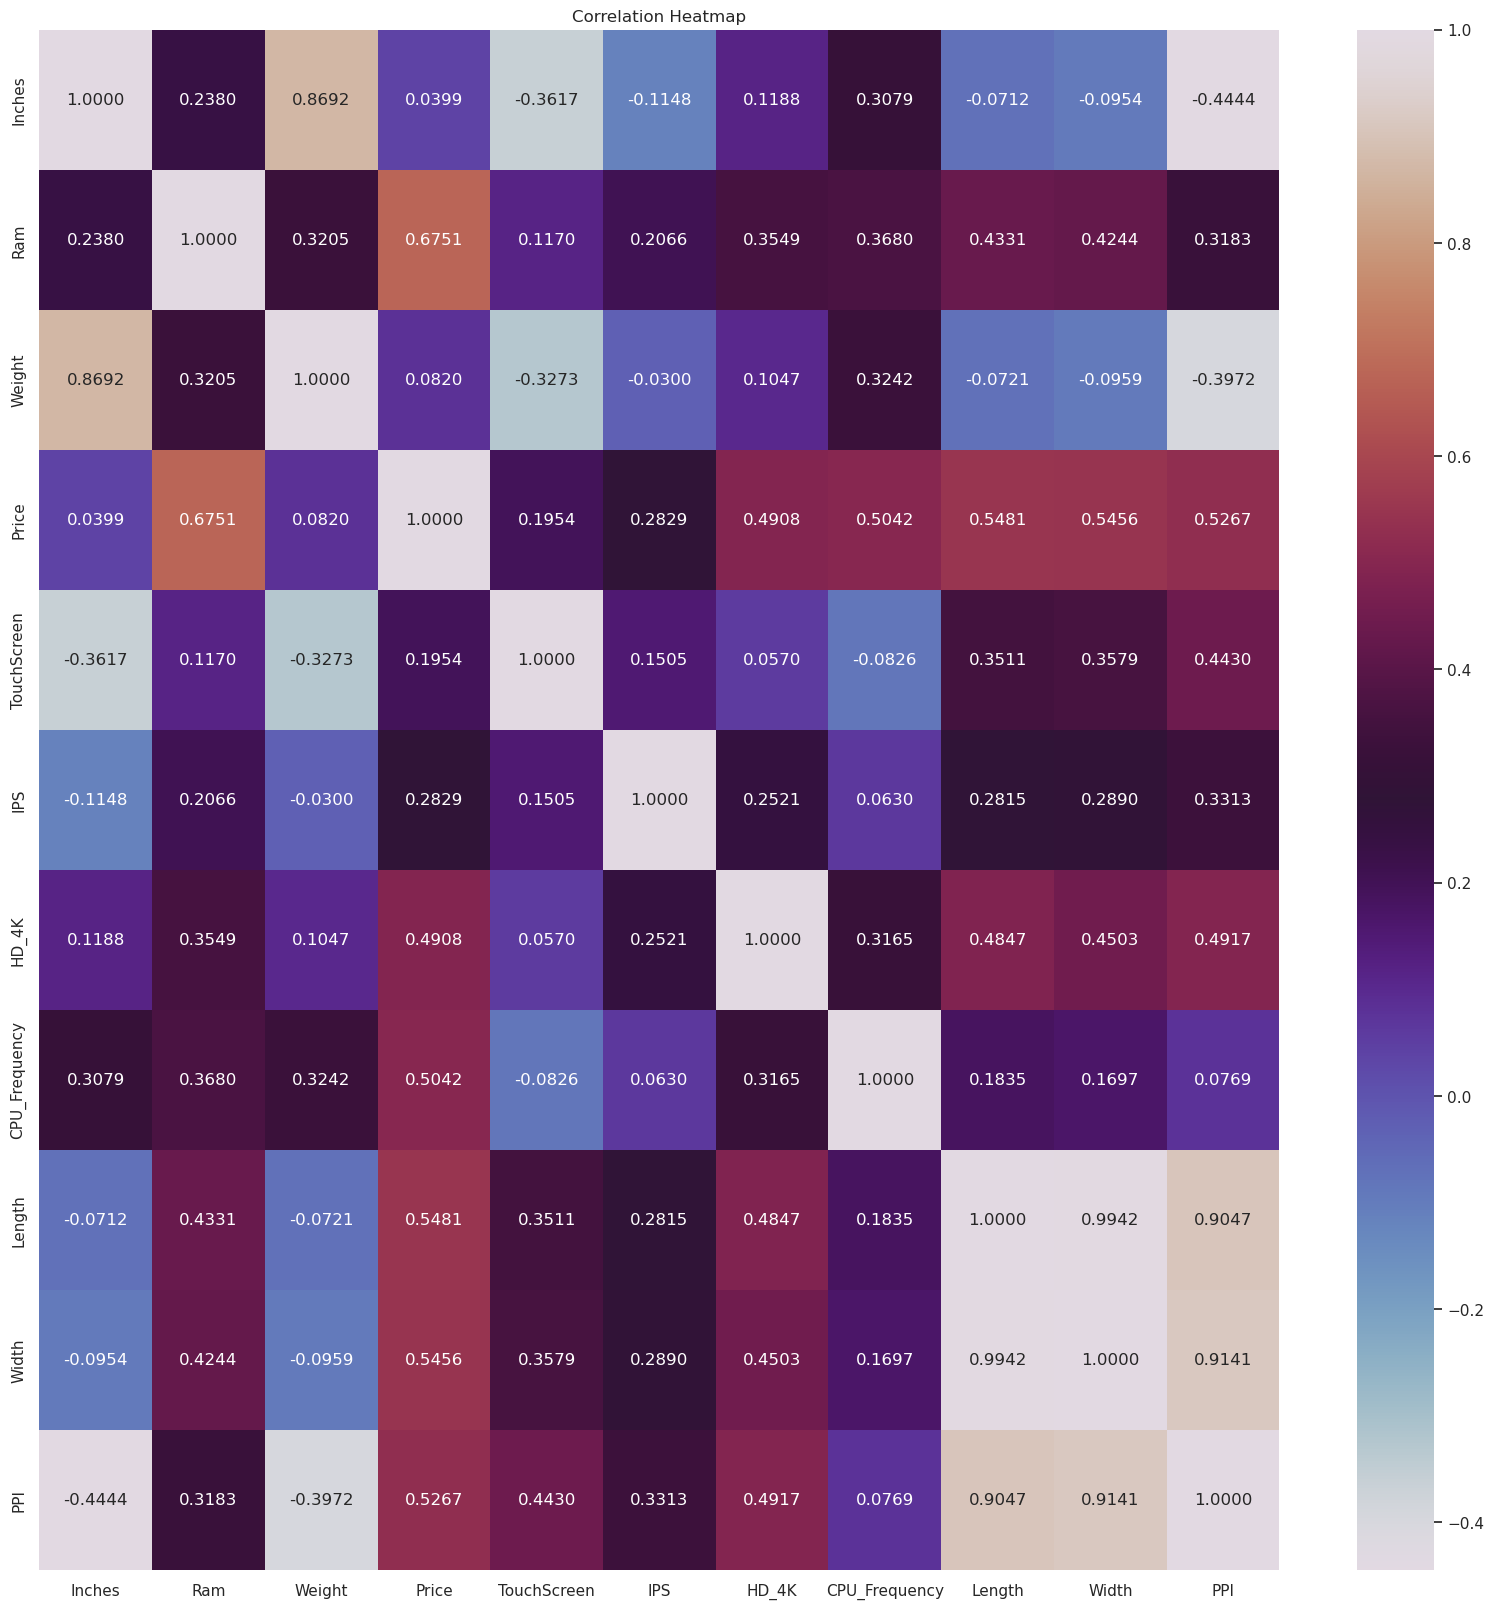

,Inches,Ram,Weight,Price,TouchScreen,IPS,HD_4K,CPU_Frequency,Length,Width,PPI
Inches,1.0,0.237993,0.869212,-,-0.361735,-,-,0.30787,-,-,-0.444368
Ram,0.237993,1.0,0.320475,0.675133,-,0.206623,0.35487,0.368,0.433121,0.424437,0.318253
Weight,0.869212,0.320475,1.0,-,-0.327295,-,-,0.3242,-,-,-0.397236
Price,-,0.675133,-,1.0,-,0.282921,0.490754,0.5042,0.548136,0.545568,0.526693
TouchScreen,-0.361735,-,-0.327295,-,1.0,-,-,-,0.351066,0.35793,0.442987
IPS,-,0.206623,-,0.282921,-,1.0,0.252117,-,0.281457,0.28903,0.331255
HD_4K,-,0.35487,-,0.490754,-,0.252117,1.0,0.316519,0.484739,0.450274,0.491712
CPU_Frequency,0.30787,0.368,0.3242,0.5042,-,-,0.316519,1.0,-,-,-
Length,-,0.433121,-,0.548136,0.351066,0.281457,0.484739,-,1.0,0.994219,0.90471
Width,-,0.424437,-,0.545568,0.35793,0.28903,0.450274,-,0.994219,1.0,0.914073


In [23]:
# Use only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

# Correlation matrix
cor_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(data=cor_matrix, cmap='twilight', annot=True, fmt='.4f')
plt.title("Correlation Heatmap")
plt.show()

# Optional: Display only significant correlations
important_corr = cor_matrix[(cor_matrix > 0.2) | (cor_matrix < -0.2)].fillna('-')
display(important_corr)


## Insights from Correlation Heatmap
- This heatmap shows how numeric features relate to each other.
- `Price` is strongly related to `Ram`, `PPI`, and `Weight`.
- Weak or no relation from `Length`, `Width`, and `CPU_Frequency`.
- Helps me pick the most useful features for my model.

In [24]:
# Optional: filter correlations above threshold for easy view
numeric_df = df.select_dtypes(include=[np.number])
cor_matrix = numeric_df.corr()
important_corr = cor_matrix[(cor_matrix > 0.2) | (cor_matrix < -0.2)].fillna('-')
display(important_corr)

# Data splitting
train, test = train_test_split(df, random_state=42)

drop_cols = ['Price', 'Inches', 'Length', 'Width', 'HD_4K']

train_X = train.drop(columns=drop_cols)
train_Y = train['Price']

test_X = test.drop(columns=drop_cols)
test_Y = test['Price']

# Dataset dimensions
print("The sizes or dimensions of the data sets are:\n")
print(f"Train: {train.shape}\nTest: {test.shape}\n")
print(f"Train_X: {train_X.shape}\nTrain_Y: {train_Y.shape}\n")
print(f"Test_X: {test_X.shape}\nTest_Y: {test_Y.shape}")


,Inches,Ram,Weight,Price,TouchScreen,IPS,HD_4K,CPU_Frequency,Length,Width,PPI
Inches,1.0,0.237993,0.869212,-,-0.361735,-,-,0.30787,-,-,-0.444368
Ram,0.237993,1.0,0.320475,0.675133,-,0.206623,0.35487,0.368,0.433121,0.424437,0.318253
Weight,0.869212,0.320475,1.0,-,-0.327295,-,-,0.3242,-,-,-0.397236
Price,-,0.675133,-,1.0,-,0.282921,0.490754,0.5042,0.548136,0.545568,0.526693
TouchScreen,-0.361735,-,-0.327295,-,1.0,-,-,-,0.351066,0.35793,0.442987
IPS,-,0.206623,-,0.282921,-,1.0,0.252117,-,0.281457,0.28903,0.331255
HD_4K,-,0.35487,-,0.490754,-,0.252117,1.0,0.316519,0.484739,0.450274,0.491712
CPU_Frequency,0.30787,0.368,0.3242,0.5042,-,-,0.316519,1.0,-,-,-
Length,-,0.433121,-,0.548136,0.351066,0.281457,0.484739,-,1.0,0.994219,0.90471
Width,-,0.424437,-,0.545568,0.35793,0.28903,0.450274,-,0.994219,1.0,0.914073


The sizes or dimensions of the data sets are:

Train: (977, 21)
Test: (326, 21)

Train_X: (977, 16)
Train_Y: (977,)

Test_X: (326, 16)
Test_Y: (326,)


### Key Point

- The dataset is split into training and testing sets.
- Ensures the model is trained on one part and tested on another for fairness.

- Dropped columns like 'Inches', 'Length', 'Width', and 'HD_4K' as they are less relevant or already represented (like through PPI).
- 'Price' is dropped from inputs and used as target variable.

- Displays the shape of training and test sets.
- Confirms that data is split correctly and ready for modeling.


In [25]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,HD_4K,CPU_Brand,GPU_Brand,Memory_Type,CPU_Frequency,Length,Width,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,0.862890,11.175769,0,1,0,Intel,Intel,SSD,2.3,2560.0,1600.0,5.429271
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,0.850151,10.776798,0,0,0,Intel,Intel,Flash Storage,1.8,1440.0,900.0,4.857313
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.050822,10.329964,0,0,1,Intel,Intel,SSD,2.5,1920.0,1080.0,4.957319
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.040277,11.814483,0,1,0,Intel,AMD,SSD,2.7,2880.0,1800.0,5.400579
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,0.862890,11.473111,0,1,0,Intel,Intel,SSD,3.1,2560.0,1600.0,5.429271


In [26]:
df.drop(columns=['ScreenResolution', 'Cpu', 'Gpu', 'Memory'], inplace=True)

In [27]:
df.select_dtypes('object').columns

Index(['Company', 'TypeName', 'OpSys', 'CPU_Brand', 'GPU_Brand',
       'Memory_Type'],
      dtype='object')

In [28]:
df.head()

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,TouchScreen,IPS,HD_4K,CPU_Brand,GPU_Brand,Memory_Type,CPU_Frequency,Length,Width,PPI
0,Apple,Ultrabook,13.3,8,macOS,0.862890,11.175769,0,1,0,Intel,Intel,SSD,2.3,2560.0,1600.0,5.429271
1,Apple,Ultrabook,13.3,8,macOS,0.850151,10.776798,0,0,0,Intel,Intel,Flash Storage,1.8,1440.0,900.0,4.857313
2,HP,Notebook,15.6,8,No OS,1.050822,10.329964,0,0,1,Intel,Intel,SSD,2.5,1920.0,1080.0,4.957319
3,Apple,Ultrabook,15.4,16,macOS,1.040277,11.814483,0,1,0,Intel,AMD,SSD,2.7,2880.0,1800.0,5.400579
4,Apple,Ultrabook,13.3,8,macOS,0.862890,11.473111,0,1,0,Intel,Intel,SSD,3.1,2560.0,1600.0,5.429271


### Key Point

- The `describe()` method provides summary statistics (mean, std, min, max, quartiles) for the laptop prices.
- The histogram with KDE shows the distribution of prices, helping to identify skewness or outliers.

<Axes: xlabel='Price', ylabel='Count'>

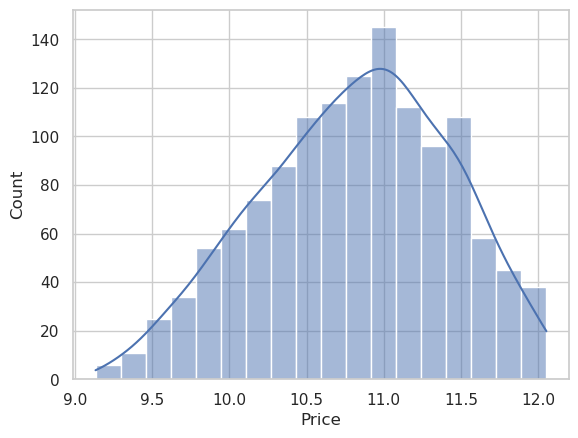

In [29]:
df['Price'].describe()
sns.histplot(df['Price'], kde=True)

In [30]:
df

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,TouchScreen,IPS,HD_4K,CPU_Brand,GPU_Brand,Memory_Type,CPU_Frequency,Length,Width,PPI
0,Apple,Ultrabook,13.3,8,macOS,0.862890,11.175769,0,1,0,Intel,Intel,SSD,2.3,2560.0,1600.0,5.429271
1,Apple,Ultrabook,13.3,8,macOS,0.850151,10.776798,0,0,0,Intel,Intel,Flash Storage,1.8,1440.0,900.0,4.857313
2,HP,Notebook,15.6,8,No OS,1.050822,10.329964,0,0,1,Intel,Intel,SSD,2.5,1920.0,1080.0,4.957319
3,Apple,Ultrabook,15.4,16,macOS,1.040277,11.814483,0,1,0,Intel,AMD,SSD,2.7,2880.0,1800.0,5.400579
4,Apple,Ultrabook,13.3,8,macOS,0.862890,11.473111,0,1,0,Intel,Intel,SSD,3.1,2560.0,1600.0,5.429271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,Windows 10,1.029619,10.433929,1,1,1,Intel,Intel,SSD,2.5,1920.0,1080.0,5.064811
1299,Lenovo,2 in 1 Convertible,13.3,16,Windows 10,0.832909,11.288127,1,1,1,Intel,Intel,SSD,2.5,3200.0,1800.0,5.624211
1300,Lenovo,Notebook,14.0,2,Windows 10,0.916291,9.409365,0,0,0,Intel,Intel,Flash Storage,1.6,1366.0,768.0,4.726814
1301,HP,Notebook,15.6,6,Windows 10,1.160021,10.614153,0,0,0,Intel,AMD,HDD,2.5,1366.0,768.0,4.619612


In [31]:
# Final cleaned dataset save
df.to_csv('../../src/FC212017-Dasun/laptop_cleaned.csv', index=False)